In [1]:
import torch
from torch import nn
from tqdm import tqdm
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2024-12-05 09:01:12.418606: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-05 09:01:12.423411: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-05 09:01:12.438473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1733389272.463305   11701 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1733389272.470801   11701 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
class TextDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts = texts
        self.targets = targets

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_tensor = self.texts[idx].clone().detach().to(device)
        target_tensor = torch.tensor(self.targets[idx], dtype=torch.float).to(device)  # Убедитесь, что это FloatTensor
        
        return text_tensor, target_tensor

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

model_name = "cointegrated/rubert-tiny2"  
# model_name = "DeepPavlov/rubert-base-cased"
num_labels = 7  

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
import pandas as pd

df = pd.read_csv('new.csv',sep="$")
df = df.dropna()
def is_convertible_to_int(x):
    try:
        list(map(int, x))
        return True
    except ValueError:
        return False
def is_seven(x):
    return len(x)==7

df = df[df['target'].apply(is_convertible_to_int)]
df = df[df['target'].apply(is_seven)]

In [5]:
df

,text,target
0,"Могу рекомендовать данный курс тем, кто начина...",1100110
1,ЛУЧШИЙ!!!!ВЕЛИКОЛЕПНЫЙ КУРС!175 ЗАДАЧ!!!! Это ...,1101111
2,"Хочу выразить огромную благодарность за курс ""...",1111111
3,"Думаю, что на данный момент это лучший курс по...",1101110
4,Прохожу уже не первый курс этого автора. Как в...,0111111
...,...,...
18646,Отлично!,0000000
18647,Всё ясно и понятно!,1000000
18648,Классный курс! Узнал много нового!,0100000
18649,"Замечательный курс для начинающих, все понятно...",1110010


In [6]:
texts = df['text'].tolist()  
df['target'] = df['target'].apply(lambda x: list(map(float,x)))
targets = df['target'].tolist()  

encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=512, 
    return_tensors='pt'
)
attention_mask = encodings['attention_mask']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(encodings['input_ids'], targets, test_size=0.2, random_state=42)

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

from torch.optim.lr_scheduler import CosineAnnealingLR

num_epochs = 100

model =  model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.BCEWithLogitsLoss()

In [8]:
import torch
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np

def train(model, train_loader, optimizer, criterion, device, num_epochs=100):
    model.train()  
    for epoch in range(num_epochs):  
        total_loss = 0
        all_predictions = []
        all_targets = []
        
        for batch in tqdm(train_loader):
            input_ids, targets = batch
            attention_mask = (input_ids != 0).type(torch.int)
            
            input_ids = input_ids.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            logits = outputs.logits
            
            probabilities = torch.sigmoid(logits)  
            
            loss = criterion(logits, targets) 
            total_loss += loss.item()
            
            all_predictions.append(probabilities.detach().cpu().numpy())
            all_targets.append(targets.detach().cpu().numpy())

            loss.backward()
            optimizer.step()

        all_predictions = np.concatenate(all_predictions)
        all_targets = np.concatenate(all_targets)

        accuracy_train = accuracy_score(all_targets, (all_predictions > 0.5).astype(float))
        f1_train = f1_score(all_targets, (all_predictions > 0.5).astype(float), average='macro')
        
        print(f'Train Loss: {total_loss:.4f}, Train Accuracy: {accuracy_train:.4f}, Train F1 Score: {f1_train:.4f}')
        
        return total_loss, accuracy_train, f1_train

In [9]:
def test(model, test_loader, criterion, device):
    model.eval()  
    total_loss = 0
    all_predictions = []
    all_targets = []

    with torch.no_grad():  
        for batch in tqdm(test_loader):
            input_ids, targets = batch
            attention_mask = (input_ids != 0).type(torch.int)
            
            input_ids = input_ids.to(device)
            targets = targets.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            logits = outputs.logits
            
            probabilities = torch.sigmoid(logits)  
            
            loss = criterion(logits, targets) 
            total_loss += loss.item()

            all_predictions.append(probabilities.detach().cpu().numpy())
            all_targets.append(targets.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)

    accuracy_test = accuracy_score(all_targets, (all_predictions > 0.5).astype(float))
    f1_test = f1_score(all_targets, (all_predictions > 0.5).astype(float), average='macro')
    
    print(f'Test Loss: {total_loss:.4f}, Test Accuracy: {accuracy_test:.4f}, Test F1 Score: {f1_test:.4f}')
    
    return total_loss, accuracy_test, f1_test

In [10]:
patience = 5  
min_delta = 0.01  
best_metric = float('inf')  
patience_counter = 0  

train_losses = []
test_losses = []
f1_train_h = []
f1_test_t = []
accuracy_test_h = []
accuracy_train_h = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}{'-'*130}")
    
    loss_train, accuracy_train, f1_train = train(model, train_loader, optimizer, criterion, device)
    loss_test, accuracy_test, f1_test = test(model, test_loader, criterion, device)
    
    
    train_losses.append(loss_train) 
    test_losses.append(loss_test)   
    accuracy_train_h.append(accuracy_train)
    accuracy_test_h.append(accuracy_test)
    f1_train_h.append(f1_train)
    f1_test_t.append(f1_test)
    
    scheduler.step()
    current_metric = accuracy_test
    
    if current_metric > best_metric - min_delta:
        best_metric = current_metric
        patience_counter = 0  
        torch.save(model.state_dict(), 'SeFeu.pth')
        print("Улучшение обнаружено! Модель сохранена.")
    elif epoch != 0:
        patience_counter += 1
        print(f"Улучшения не обнаружено. Счетчик терпения: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Ранняя остановка")
        break


Epoch 1/100----------------------------------------------------------------------------------------------------------------------------------


100%|██████████| 466/466 [00:40<00:00, 11.55it/s]


Train Loss: 182.0149, Train Accuracy: 0.3457, Train F1 Score: 0.6181


100%|██████████| 117/117 [00:03<00:00, 34.39it/s]


Test Loss: 37.7734, Test Accuracy: 0.4030, Test F1 Score: 0.7282
Epoch 2/100----------------------------------------------------------------------------------------------------------------------------------


...

Test Loss: 29.6263, Test Accuracy: 0.5398, Test F1 Score: 0.8061
Улучшения не обнаружено. Счетчик терпения: 4/5
Epoch 6/100----------------------------------------------------------------------------------------------------------------------------------


100%|██████████| 466/466 [00:39<00:00, 11.70it/s]


Train Loss: 62.2645, Train Accuracy: 0.7206, Train F1 Score: 0.9156


100%|██████████| 117/117 [00:03<00:00, 34.50it/s]

Test Loss: 34.0244, Test Accuracy: 0.5229, Test F1 Score: 0.8104
Улучшения не обнаружено. Счетчик терпения: 5/5
Ранняя остановка


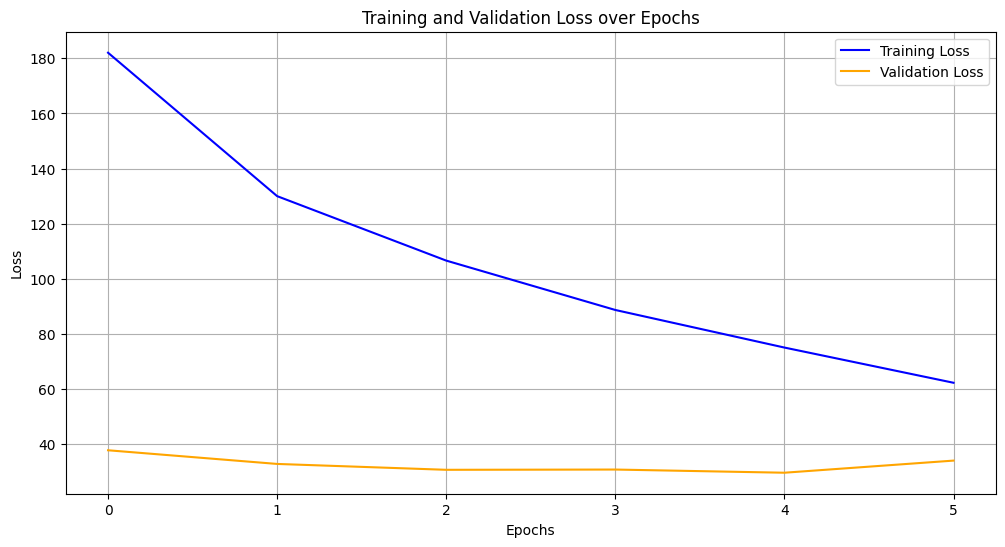

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(test_losses, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

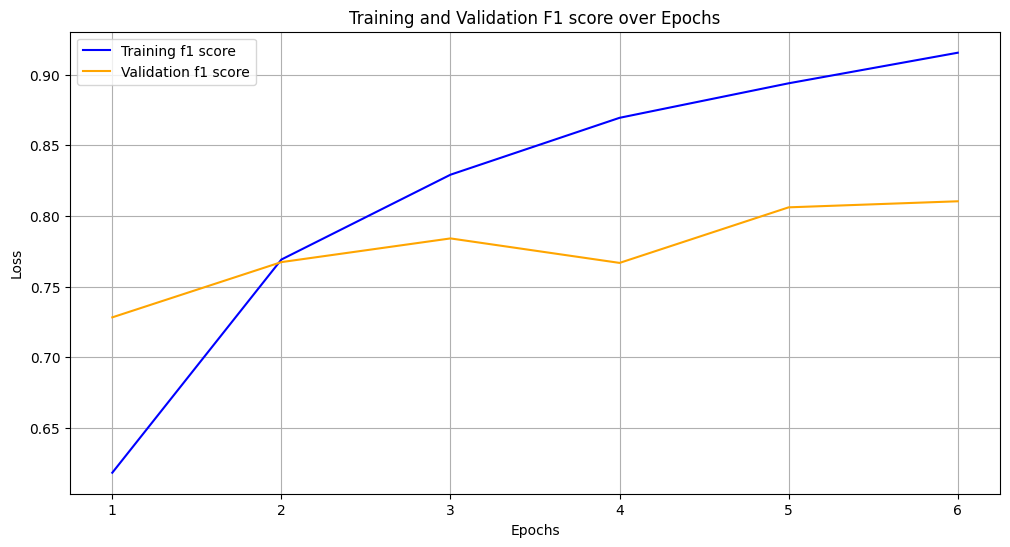

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(f1_train_h) + 1), f1_train_h, label='Training f1 score', color='blue')
plt.plot(range(1, len(f1_train_h) + 1), f1_test_t, label='Validation f1 score', color='orange')
plt.title('Training and Validation F1 score over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

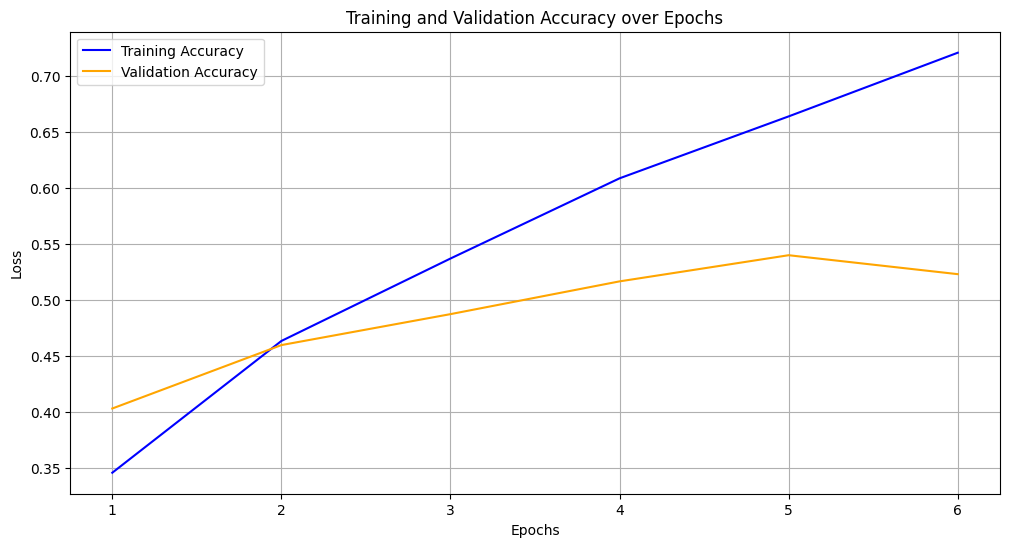

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(f1_train_h) + 1), accuracy_train_h, label='Training Accuracy', color='blue')
plt.plot(range(1, len(f1_train_h) + 1), accuracy_test_h, label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()